In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/datasetengineer/drone-communication-dataset/drone_communication_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

PALETTE = [
    '#378ADD', '#E24B4A', '#D85A30', '#BA7517',
    '#7F77DD', '#1D9E75', '#D4537E', '#888780'
]

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
file_path = "/kaggle/input/datasets/datasetengineer/drone-communication-dataset/drone_communication_dataset.csv"

# Load CSV
df = pd.read_csv(file_path)

# Preview data
df.head()

,timestamp,signal_strength,packet_loss_rate,round_trip_time,communication_protocol,frequency_band,encryption_type,drone_gps_coordinates,altitude,speed_trajectory,...,intrusion_detection_flags,temporal_patterns,label_normal,label_spoofing,label_mitm,label_ddos,label_gps_spoofing,label_malware,label_jamming,label_protocol_exploit
0,2019-11-01 00:00:00,-60,0,50,ZigBee,5.0,AES,"(-11.69864152850468, 86.89778588010734)",291,60,...,0,0,0,0,0,0,0,0,0,0
1,2019-11-01 01:00:00,-64,0,50,LoRa,2.4,AES,"(66.98918792506822, -140.91891468822496)",100,48,...,0,0,0,0,0,0,0,0,0,0
2,2019-11-01 02:00:00,-60,0,194,ZigBee,2.4,AES,"(-31.711586784829194, 36.5632095665857)",226,30,...,0,0,0,0,0,0,0,0,0,0
3,2019-11-01 03:00:00,-60,0,50,Wi-Fi,2.4,AES,"(3.5943733073538198, 74.7992608739666)",100,30,...,0,0,1,0,0,0,0,0,1,0
4,2019-11-01 04:00:00,-69,0,50,Wi-Fi,2.4,Plain-text,"(41.4738797417983, -100.00817301602393)",100,30,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print('=== Column Data Types ===')
print(df.dtypes)
print()
print('=== Memory Usage ===')
print(f'{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')

=== Column Data Types ===
timestamp                         object
signal_strength                    int64
packet_loss_rate                   int64
round_trip_time                    int64
communication_protocol            object
frequency_band                   float64
encryption_type                   object
drone_gps_coordinates             object
altitude                           int64
speed_trajectory                   int64
transmission_power                 int64
message_authentication_status      int64
session_key_validity               int64
signal_noise_ratio                 int64
sequence_number_gap                int64
drone_identification               int64
data_rate                          int64
network_traffic_volume             int64
gps_signal_integrity               int64
uplink_downlink_quality            int64
base_station_load                  int64
port_scanning_attempts             int64
drone_signal_handoff               int64
malware_detection_signals      

In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values found — dataset is complete.')

=== Missing Values ===
No missing values found — dataset is complete.


In [6]:
print('=== Descriptive Statistics (numeric) ===')
df.describe().T

=== Descriptive Statistics (numeric) ===


,count,mean,std,min,25%,50%,75%,max
signal_strength,45289.0,-60.439312,5.179791,-85.0,-60.0,-60.0,-60.0,-41.0
packet_loss_rate,45289.0,2.546711,8.856450,0.0,0.0,0.0,0.0,49.0
round_trip_time,45289.0,100.021286,112.560687,50.0,50.0,50.0,50.0,499.0
frequency_band,45289.0,185.465914,364.475786,2.4,2.4,5.0,5.0,915.0
altitude,45289.0,115.423812,63.910651,20.0,100.0,100.0,100.0,499.0
speed_trajectory,45289.0,33.322816,13.182603,5.0,30.0,30.0,30.0,99.0
transmission_power,45289.0,20.795116,5.034346,5.0,20.0,20.0,20.0,49.0
message_authentication_status,45289.0,0.900439,0.299417,0.0,1.0,1.0,1.0,1.0
session_key_validity,45289.0,0.849610,0.357457,0.0,1.0,1.0,1.0,1.0
signal_noise_ratio,45289.0,29.692398,4.213226,5.0,30.0,30.0,30.0,49.0


## Label Analysis

=== Label Counts ===
label_normal              4608
label_ddos                3671
label_jamming             3186
label_malware             2776
label_spoofing            2258
label_gps_spoofing        1855
label_mitm                1369
label_protocol_exploit     955
dtype: int64


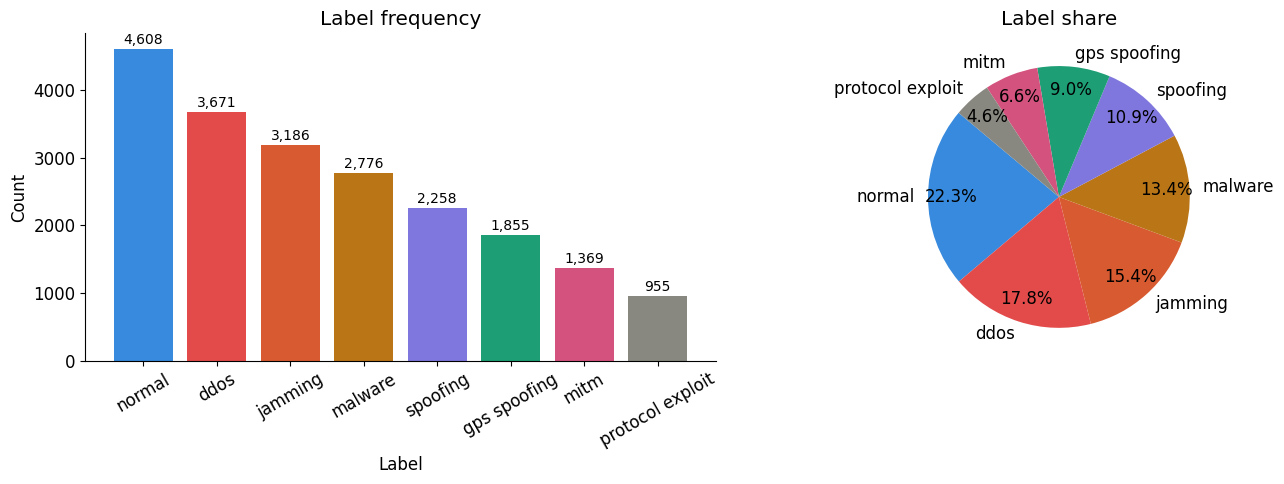

In [7]:
label_cols = [c for c in df.columns if c.startswith('label_')]
attack_cols = [c for c in label_cols if c != 'label_normal']

label_counts = df[label_cols].sum().sort_values(ascending=False)
print('=== Label Counts ===')
print(label_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
short_names = [c.replace('label_', '').replace('_', ' ') for c in label_counts.index]
bars = axes[0].bar(short_names, label_counts.values, color=PALETTE[:len(label_counts)])
axes[0].set_title('Label frequency')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(label_counts.values, labels=short_names, colors=PALETTE[:len(label_counts)],
            autopct='%1.1f%%', startangle=140, pctdistance=0.82)
axes[1].set_title('Label share')

plt.tight_layout()
plt.show()

=== Rows by number of labels ===
label_count
Unlabeled    28225
1 label      13838
2 labels      2875
3 labels       315
4 labels        35
5 labels         1
Name: count, dtype: int64


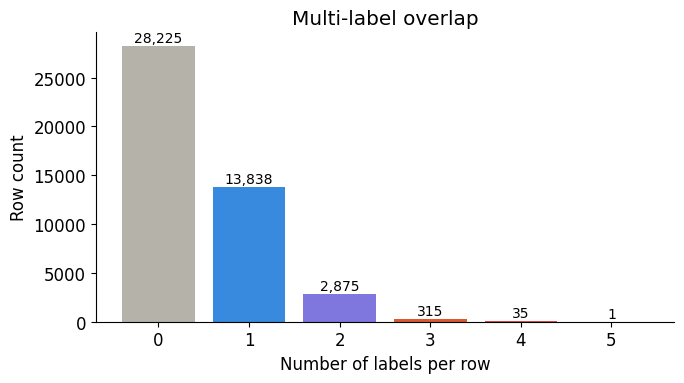

In [8]:
# Multi-label overlap
df['label_count'] = df[label_cols].sum(axis=1)
overlap = df['label_count'].value_counts().sort_index()

print('=== Rows by number of labels ===')
print(overlap.rename({0:'Unlabeled', 1:'1 label', 2:'2 labels', 3:'3 labels', 4:'4 labels', 5:'5 labels'}))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#B4B2A9', '#378ADD', '#7F77DD', '#D85A30', '#E24B4A', '#BA7517']
bars = ax.bar([str(i) for i in overlap.index], overlap.values, color=colors[:len(overlap)])
ax.set_title('Multi-label overlap')
ax.set_xlabel('Number of labels per row')
ax.set_ylabel('Row count')
for bar, val in zip(bars, overlap.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Categorical Feature Analysis

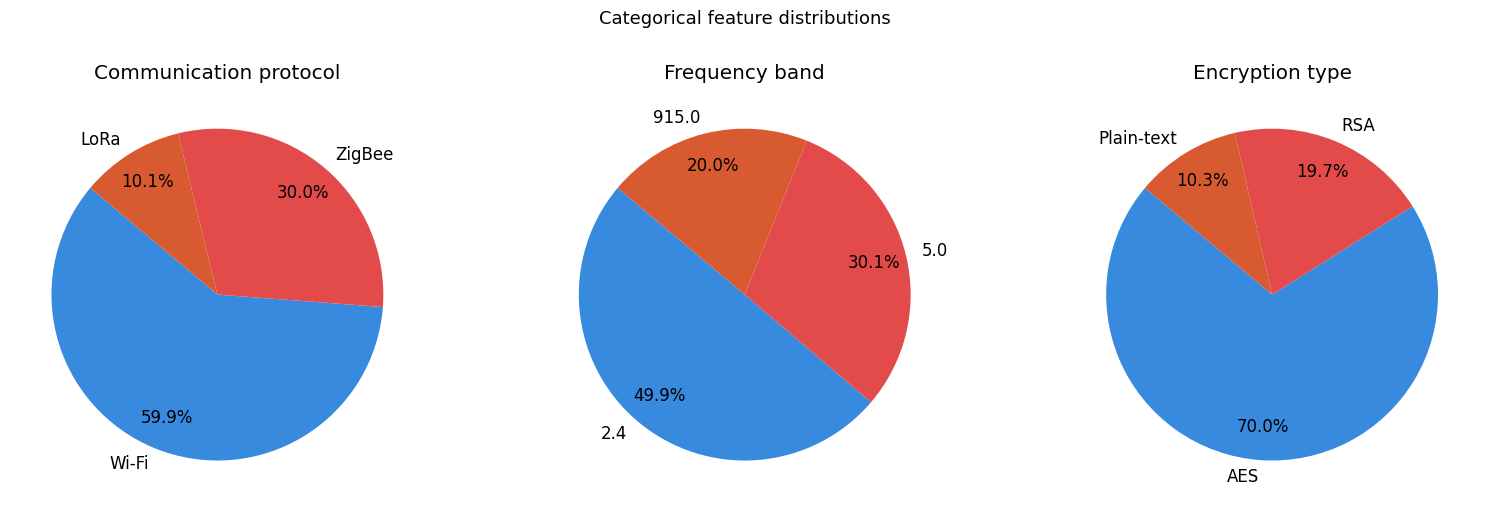

In [9]:
cat_cols = ['communication_protocol', 'frequency_band', 'encryption_type']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts.values, labels=counts.index,
        colors=PALETTE[:len(counts)],
        autopct='%1.1f%%', startangle=140, pctdistance=0.80
    )
    ax.set_title(col.replace('_', ' ').capitalize())

plt.suptitle('Categorical feature distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

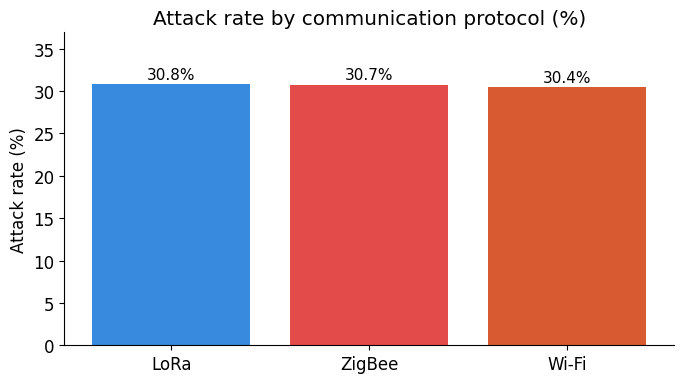

In [10]:
# Attack type breakdown per communication protocol
df['any_attack'] = df[attack_cols].max(axis=1)

proto_attack = df.groupby('communication_protocol')['any_attack'].mean() * 100
proto_attack = proto_attack.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(proto_attack.index, proto_attack.values, color=PALETTE[:3])
ax.set_title('Attack rate by communication protocol (%)')
ax.set_ylabel('Attack rate (%)')
ax.set_ylim(0, proto_attack.max() * 1.2)
for bar, val in zip(bars, proto_attack.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## Numeric Feature Distributions

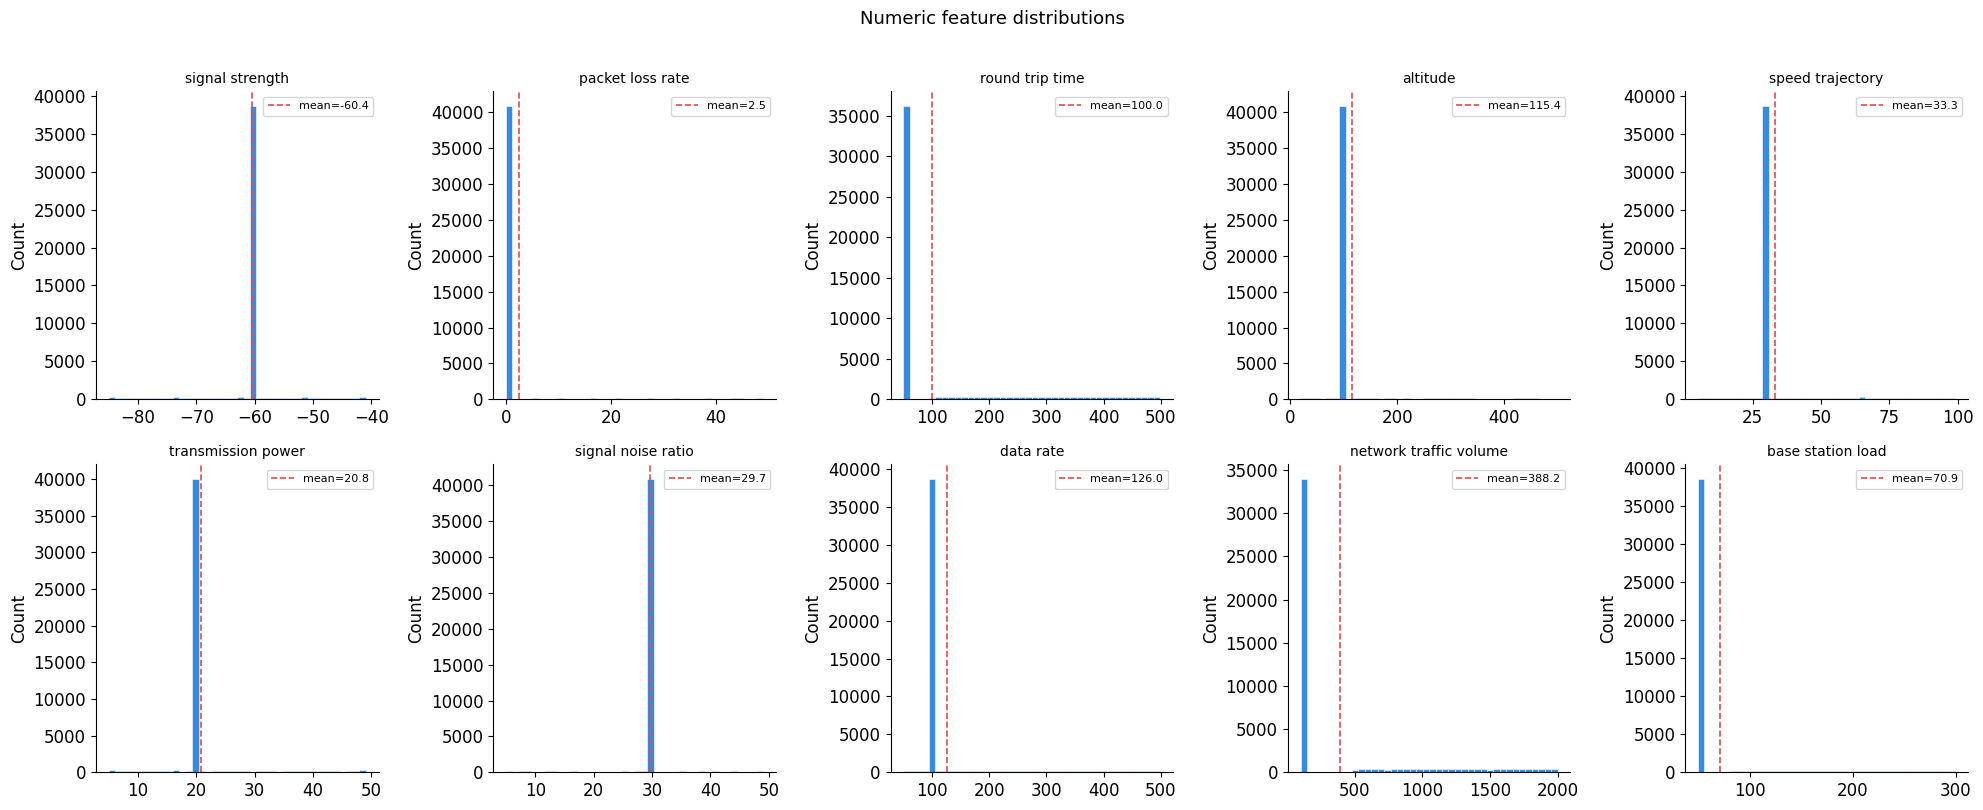

In [11]:
numeric_features = [
    'signal_strength', 'packet_loss_rate', 'round_trip_time',
    'altitude', 'speed_trajectory', 'transmission_power',
    'signal_noise_ratio', 'data_rate', 'network_traffic_volume',
    'base_station_load'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    ax.hist(df[col], bins=40, color='#378ADD', edgecolor='white', linewidth=0.4)
    ax.set_title(col.replace('_', ' '), fontsize=10)
    ax.set_ylabel('Count')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#E24B4A', linestyle='--', linewidth=1.2, label=f'mean={mean_val:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Numeric feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

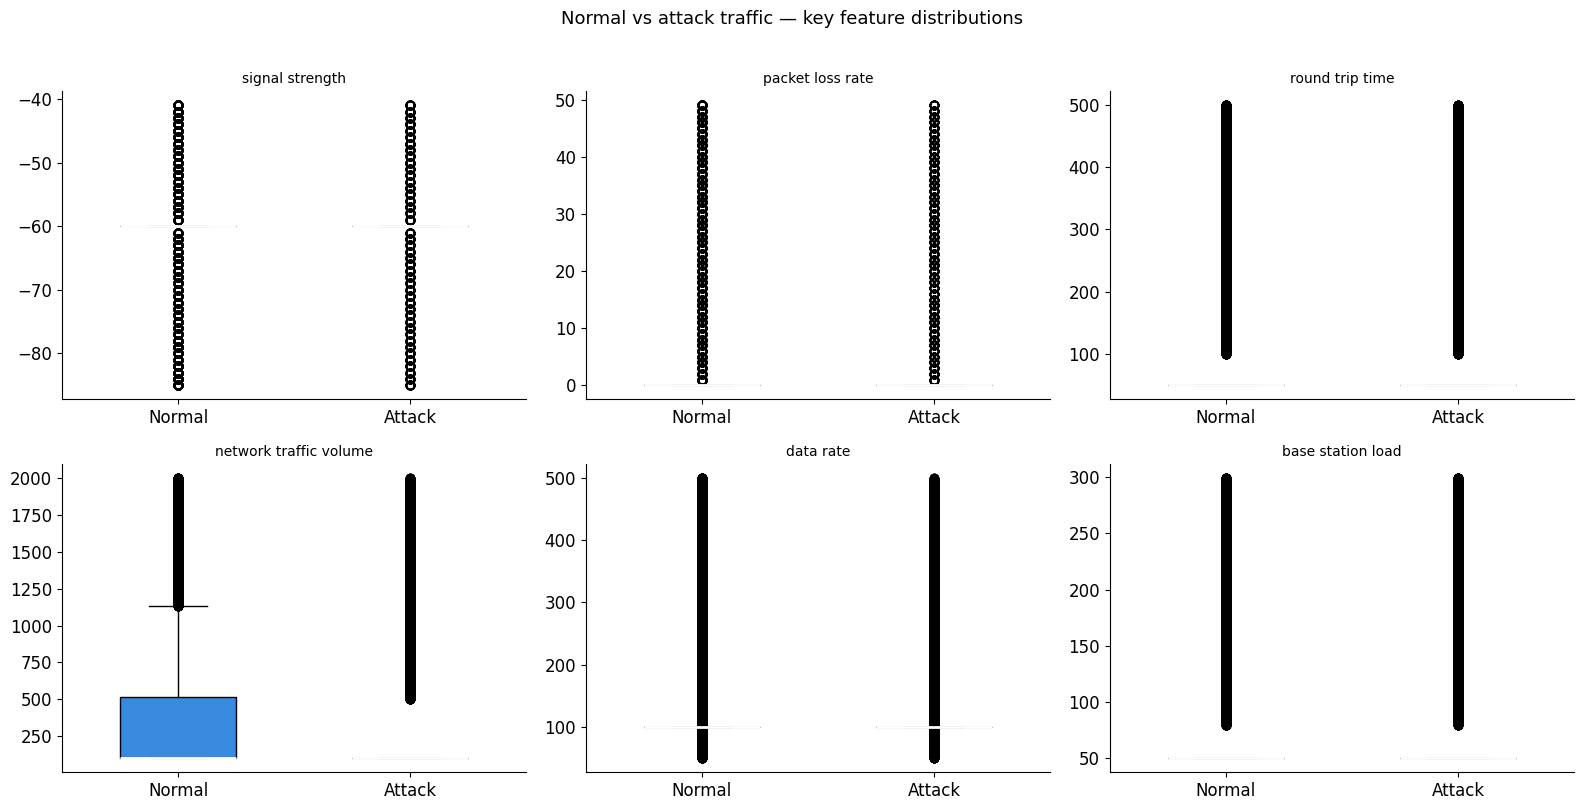

In [12]:
# Box plots: attack vs normal
key_features = ['signal_strength', 'packet_loss_rate', 'round_trip_time',
                'network_traffic_volume', 'data_rate', 'base_station_load']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, key_features):
    normal_data = df[df['any_attack'] == 0][col]
    attack_data = df[df['any_attack'] == 1][col]
    bp = ax.boxplot([normal_data, attack_data], labels=['Normal', 'Attack'],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('#378ADD')
    bp['boxes'][1].set_facecolor('#E24B4A')
    ax.set_title(col.replace('_', ' '), fontsize=10)

plt.suptitle('Normal vs attack traffic — key feature distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Anomaly / Security Feature Analysis

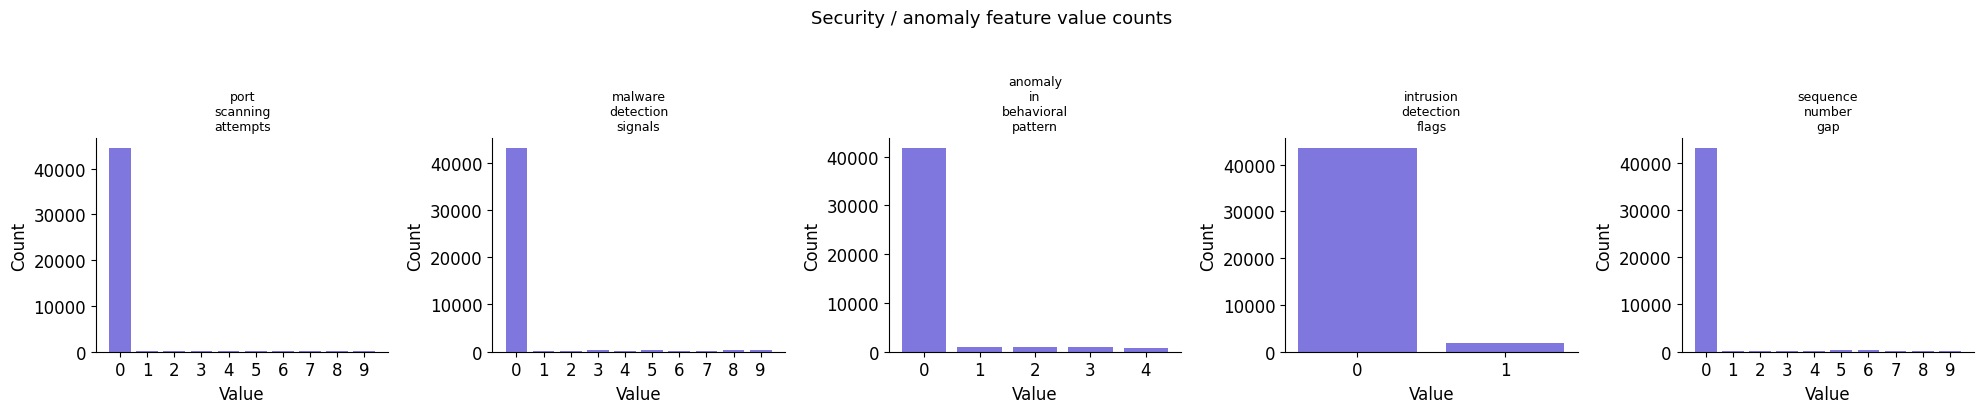

In [13]:
security_features = [
    'port_scanning_attempts', 'malware_detection_signals',
    'anomaly_in_behavioral_pattern', 'intrusion_detection_flags',
    'sequence_number_gap'
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, col in zip(axes, security_features):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color='#7F77DD')
    ax.set_title(col.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Security / anomaly feature value counts', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

In [14]:
# Non-zero rates for security features
print('=== Non-zero occurrence rate for security features ===')
for col in security_features:
    rate = (df[col] > 0).mean() * 100
    print(f'  {col:<40} {rate:.2f}%')

=== Non-zero occurrence rate for security features ===
  port_scanning_attempts                   2.00%
  malware_detection_signals                5.00%
  anomaly_in_behavioral_pattern            8.00%
  intrusion_detection_flags                4.00%
  sequence_number_gap                      5.00%


## Correlation Analysis

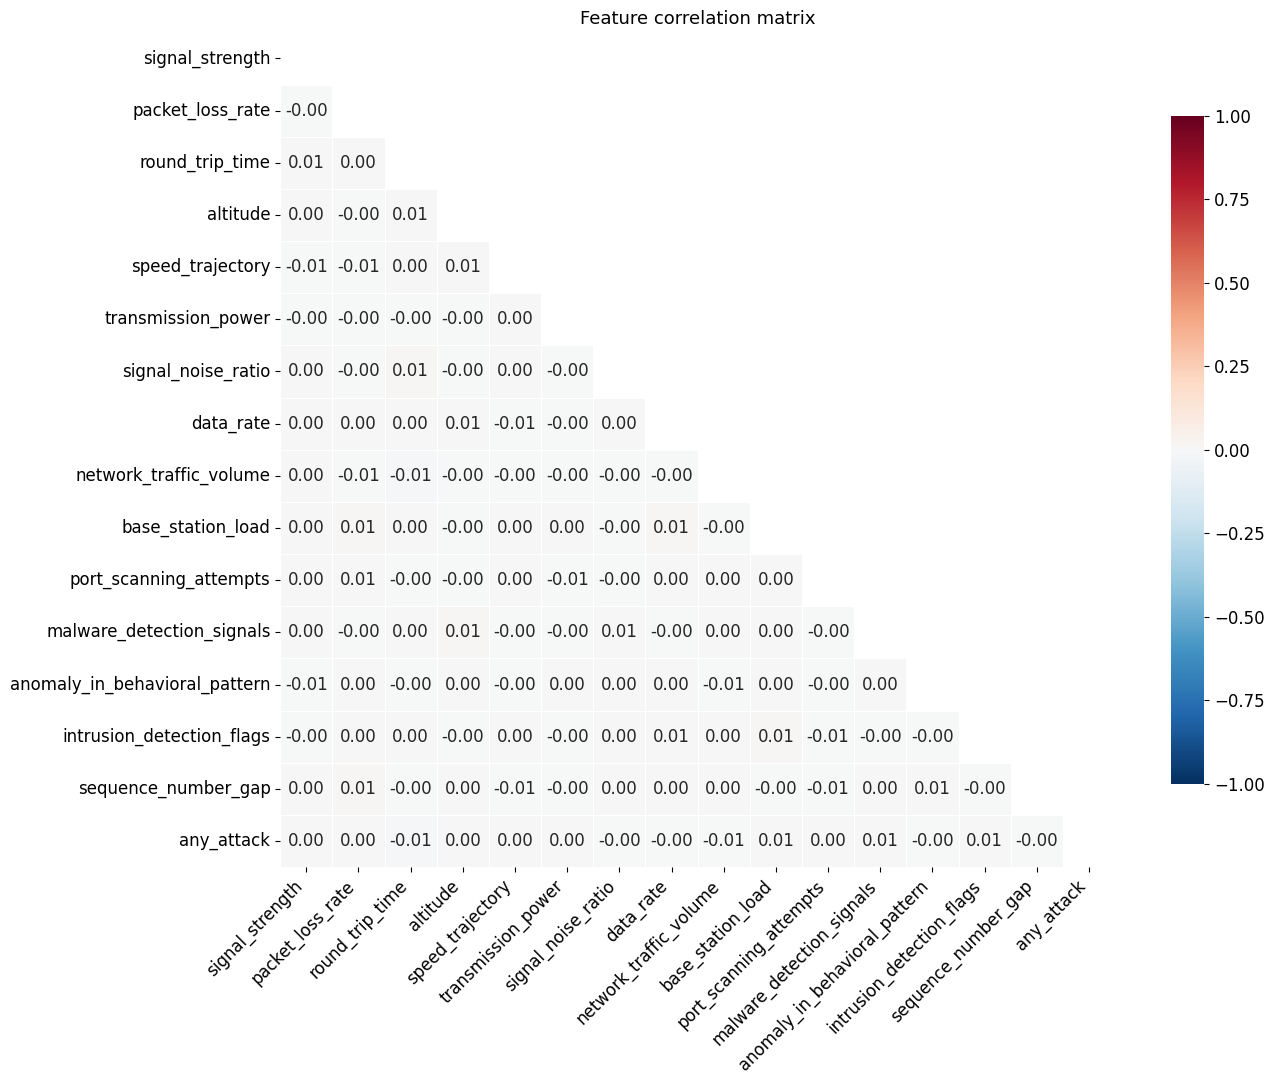

In [15]:
# Correlation heatmap (numeric features + any_attack)
corr_features = numeric_features + security_features + ['any_attack']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Feature correlation matrix', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

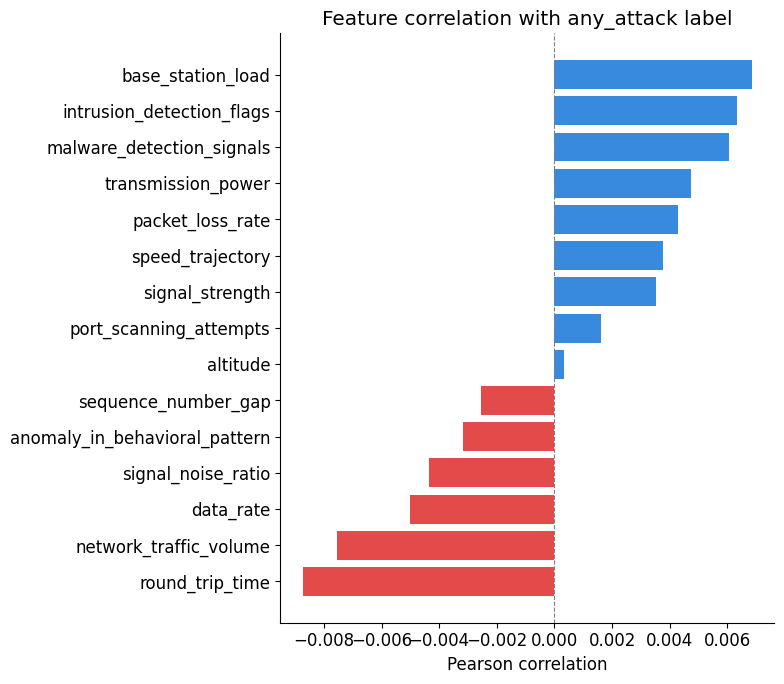

In [16]:
# Feature correlation with any_attack — horizontal bar
corr_with_attack = df[numeric_features + security_features + ['any_attack']].corr()['any_attack'].drop('any_attack')
corr_with_attack = corr_with_attack.sort_values()

colors = ['#E24B4A' if v < 0 else '#378ADD' for v in corr_with_attack.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(corr_with_attack.index, corr_with_attack.values, color=colors)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Feature correlation with any_attack label')
ax.set_xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

## Per-Attack-Type Feature Profiles

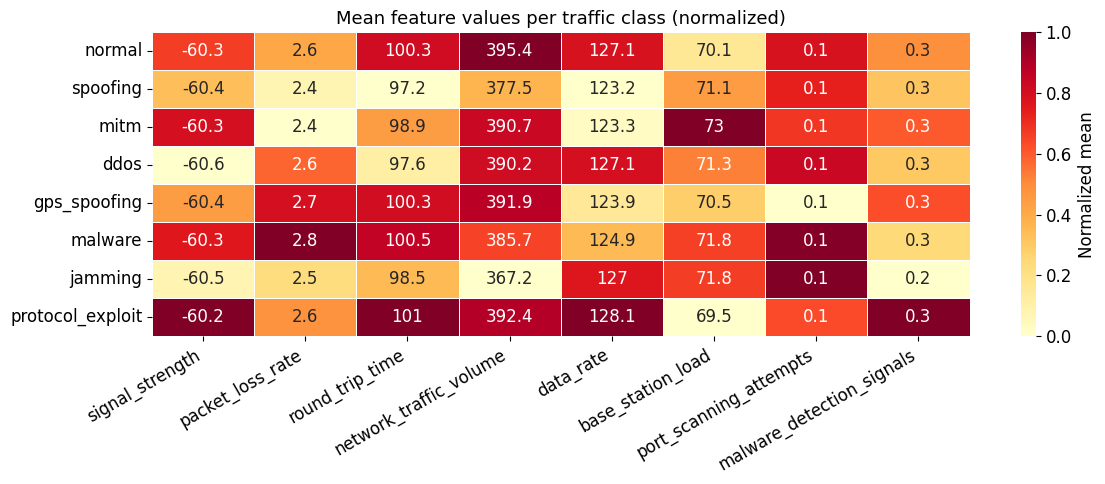

In [17]:
# Mean feature values per attack type vs normal
profile_features = ['signal_strength', 'packet_loss_rate', 'round_trip_time',
                     'network_traffic_volume', 'data_rate', 'base_station_load',
                     'port_scanning_attempts', 'malware_detection_signals']

profiles = {}
profiles['normal'] = df[df['label_normal'] == 1][profile_features].mean()
for col in attack_cols:
    name = col.replace('label_', '')
    profiles[name] = df[df[col] == 1][profile_features].mean()

profile_df = pd.DataFrame(profiles).T

# Normalize for radar-style heatmap
profile_norm = (profile_df - profile_df.min()) / (profile_df.max() - profile_df.min())

plt.figure(figsize=(12, 5))
sns.heatmap(profile_norm, annot=profile_df.round(1), fmt='g',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Normalized mean'})
plt.title('Mean feature values per traffic class (normalized)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Time Series Overview

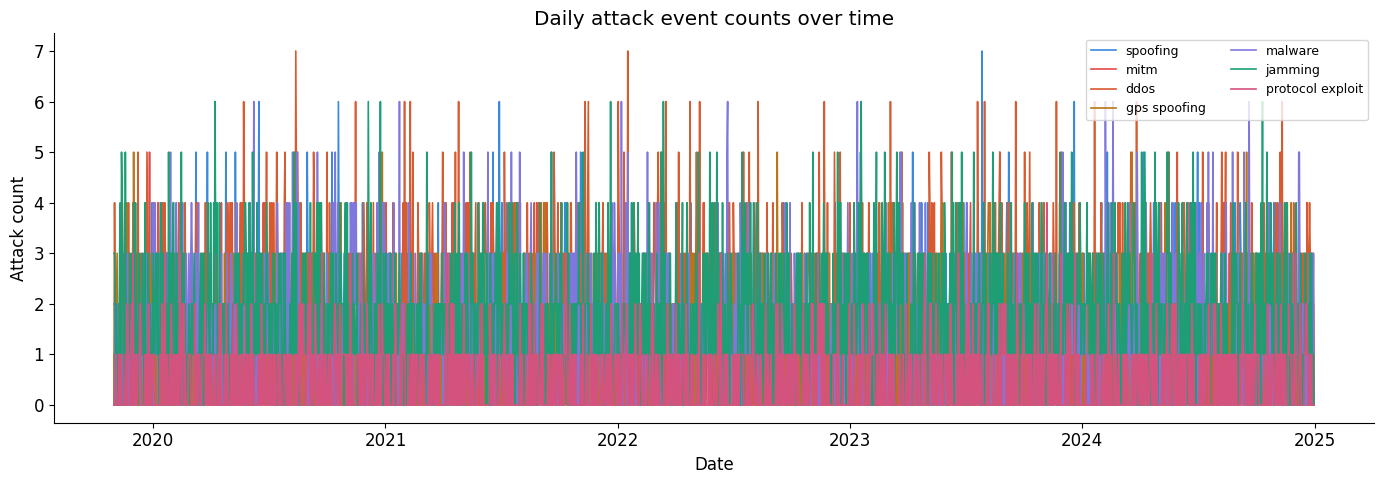

In [18]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_ts = df.set_index('timestamp').sort_index()

# Daily attack counts
daily_attacks = df_ts[attack_cols].resample('D').sum()

fig, ax = plt.subplots(figsize=(14, 5))
for i, col in enumerate(attack_cols):
    name = col.replace('label_', '').replace('_', ' ')
    ax.plot(daily_attacks.index, daily_attacks[col],
            label=name, color=PALETTE[i], linewidth=1.2)

ax.set_title('Daily attack event counts over time')
ax.set_xlabel('Date')
ax.set_ylabel('Attack count')
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

## Zero-Variance & Constant Features

In [19]:
numeric_df = df.select_dtypes(include='number')
zero_var = numeric_df.std()[numeric_df.std() == 0]

print('=== Zero-variance (constant) features ===')
if len(zero_var):
    for col in zero_var.index:
        print(f'  {col}: constant value = {numeric_df[col].iloc[0]}')
else:
    print('  None found.')

print()
low_var = numeric_df.std().sort_values().head(10)
print('=== 10 lowest-variance features ===')
print(low_var)

=== Zero-variance (constant) features ===
  gps_signal_integrity: constant value = 1
  drone_signal_handoff: constant value = 1

=== 10 lowest-variance features ===
gps_signal_integrity         0.000000
drone_signal_handoff         0.000000
label_protocol_exploit       0.143675
label_mitm                   0.171216
intrusion_detection_flags    0.195932
label_gps_spoofing           0.198198
label_spoofing               0.217653
label_malware                0.239874
label_jamming                0.255736
label_ddos                   0.272926
dtype: float64


## Summary & Recommendations

In [20]:
total = len(df)
n_attack = df['any_attack'].sum()
n_normal = df['label_normal'].sum()
n_unlabeled = (df['label_count'] == 0).sum()
n_multilabel = (df['label_count'] >= 2).sum()

print('=' * 55)
print('  DRONE COMMUNICATION DATASET — EDA SUMMARY')
print('=' * 55)
print(f'  Total rows           : {total:>10,}')
print(f'  Total columns        : {df.shape[1]:>10}')
print(f'  Missing values       : {df.isnull().sum().sum():>10}')
print(f'  Normal traffic rows  : {n_normal:>10,}  ({n_normal/total*100:.1f}%)')
print(f'  Attack rows          : {n_attack:>10,}  ({n_attack/total*100:.1f}%)')
print(f'  Unlabeled rows       : {n_unlabeled:>10,}  ({n_unlabeled/total*100:.1f}%)')
print(f'  Multi-label rows     : {n_multilabel:>10,}  ({n_multilabel/total*100:.1f}%)')
print('=' * 55)
print()
print('KEY FINDINGS:')
print('  1. No missing values — dataset is complete.')
print('  2. Dataset is multi-label: rows can carry multiple attack types.')
print('  3. 62% of rows carry no label — may represent benign unlabeled traffic.')
print('  4. Class imbalance: DDoS & Jamming dominate; Protocol Exploit is rare.')
print('  5. gps_signal_integrity and drone_signal_handoff are constant — drop before modeling.')
print('  6. Individual feature correlations with attack labels are very weak (<0.01),')
print('     suggesting non-linear separability — use tree-based or deep learning models.')
print('  7. 10.3% of traffic uses plain-text encryption — a key security risk indicator.')
print()
print('RECOMMENDED NEXT STEPS:')
print('  - Drop zero-variance features before modeling.')
print('  - Apply SMOTE or class-weighting to address label imbalance.')
print('  - Consider multi-label classification (e.g., XGBoost, Random Forest).')
print('  - Investigate the 28k unlabeled rows — semi-supervised learning may help.')
print('  - Engineer features from GPS coordinates (e.g., latitude, longitude separately).')

  DRONE COMMUNICATION DATASET — EDA SUMMARY
  Total rows           :     45,289
  Total columns        :         37
  Missing values       :          0
  Normal traffic rows  :      4,608  (10.2%)
  Attack rows          :     13,831  (30.5%)
  Unlabeled rows       :     28,225  (62.3%)
  Multi-label rows     :      3,226  (7.1%)

KEY FINDINGS:
  1. No missing values — dataset is complete.
  2. Dataset is multi-label: rows can carry multiple attack types.
  3. 62% of rows carry no label — may represent benign unlabeled traffic.
  4. Class imbalance: DDoS & Jamming dominate; Protocol Exploit is rare.
  5. gps_signal_integrity and drone_signal_handoff are constant — drop before modeling.
  6. Individual feature correlations with attack labels are very weak (<0.01),
     suggesting non-linear separability — use tree-based or deep learning models.
  7. 10.3% of traffic uses plain-text encryption — a key security risk indicator.

RECOMMENDED NEXT STEPS:
  - Drop zero-variance features before